#  Задание №1. Геометрия в пространстве признаков

=== Задание 1. Геометрия данных ===

Число объектов: 37784
Число признаков: 3
Признаки: RoundID (раунд турнира), MatchID (идентификатор матча), ShirtNumber (номер на футболке игрока)



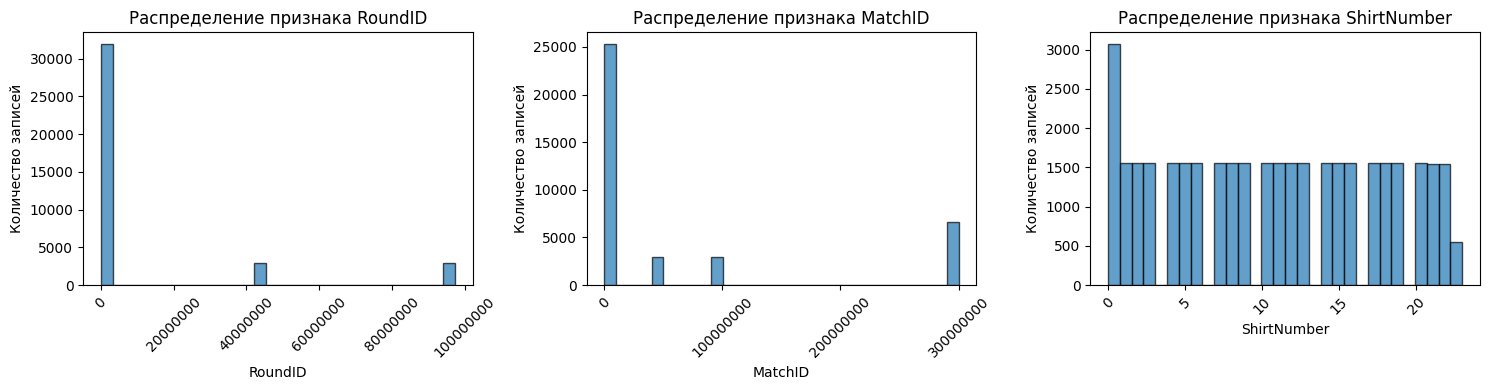

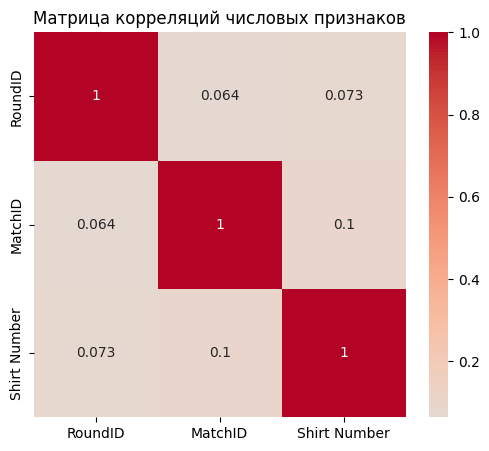

Анализ корреляции:
               RoundID   MatchID  Shirt Number
RoundID       1.000000  0.064068      0.072988
MatchID       0.064068  1.000000      0.103669
Shirt Number  0.072988  0.103669      1.000000

Выводы:
- Корреляция между RoundID и MatchID очень слабая (около 0.064). Это значит, что эти признаки почти не связаны. MatchID не определяет RoundID, и наоборот.
- Shirt Number также почти не коррелирует с RoundID и MatchID (корреляции близки к нулю).
- Никакого дублирования информации между признаками нет. Все три признака можно использовать в анализе.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WorldCupPlayers.csv")
numeric_cols = ['RoundID', 'MatchID', 'Shirt Number']
data_num = df[numeric_cols].dropna()
X = data_num.values

print("=== Задание 1. Геометрия данных ===\n")
print(f"Число объектов: {X.shape[0]}")
print(f"Число признаков: {X.shape[1]}")
print("Признаки: RoundID (раунд турнира), MatchID (идентификатор матча), ShirtNumber (номер на футболке игрока)\n")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))


for i, col in enumerate(numeric_cols):

    col_display = col.replace(' ', '')

    axes[i].hist(X[:, i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение признака {col_display}')
    axes[i].set_xlabel(col_display)
    axes[i].set_ylabel('Количество записей')


    axes[i].ticklabel_format(style='plain', axis='x')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()


corr_matrix = data_num.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых признаков')
plt.show()

print("Анализ корреляции:")
print(corr_matrix)
print("\nВыводы:")
print("- Корреляция между RoundID и MatchID очень слабая (около 0.064). Это значит, что эти признаки почти не связаны. MatchID не определяет RoundID, и наоборот.")
print("- Shirt Number также почти не коррелирует с RoundID и MatchID (корреляции близки к нулю).")
print("- Никакого дублирования информации между признаками нет. Все три признака можно использовать в анализе.")

#  Задание № 2. Реализация PCA и справнение с sklearn


=== Задание 2. PCA с нуля ===

Собственные значения: [1.16180922 0.94258802 0.89568216]

Проекция (наша реализация) – первые 5 строк:
[[-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]]

Проекция (sklearn) – первые 5 строк:
[[-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]
 [-1.49144046  0.34308782]]

Различие (норма): 6.331240596605299e-13


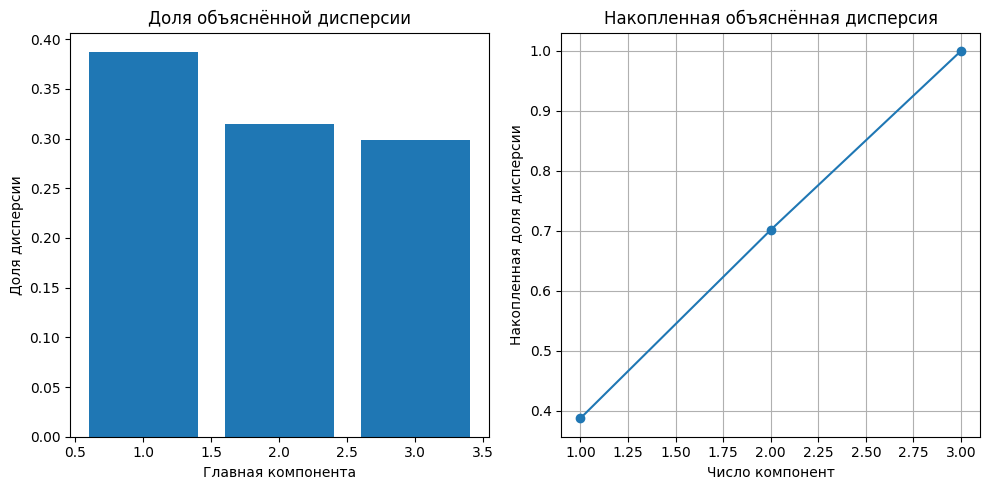

1. Компонент, объясняющих 80% дисперсии: 3
2. Компонент, объясняющих 95% дисперсии: 3

Всего строк: 37784
Уникальных комбинаций: 17078


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


cov_matrix = np.cov(X_scaled.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

k = 2
projected_my = X_scaled @ eigenvectors[:, :k]


pca_sklearn = PCA(n_components=k)
projected_sklearn = pca_sklearn.fit_transform(X_scaled)

print("\n=== Задание 2. PCA с нуля ===\n")
print("Собственные значения:", eigenvalues)
print("\nПроекция (наша реализация) – первые 5 строк:")
print(projected_my[:5])
print("\nПроекция (sklearn) – первые 5 строк:")
print(projected_sklearn[:5])
print("\nРазличие (норма):", np.linalg.norm(np.abs(projected_my) - np.abs(projected_sklearn)))


explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.title('Доля объяснённой дисперсии')
plt.xlabel('Главная компонента')
plt.ylabel('Доля дисперсии')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-')
plt.title('Накопленная объяснённая дисперсия')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

n80 = np.argmax(cumulative_variance >= 0.8) + 1
n95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"1. Компонент, объясняющих 80% дисперсии: {n80}")
print(f"2. Компонент, объясняющих 95% дисперсии: {n95}\n")




# Задание №3. Интерпретация главных компонент

In [ ]:
print("\n=== Задание 3. Интерпретация главных компонент ===\n")

n_comp = min(3, X.shape[1])
pca_full = PCA(n_components=n_comp)
pca_full.fit(X_scaled)

for i in range(n_comp):
    print(f"\nГлавная компонента {i+1}:")
    coef = pca_full.components_[i]
    for j, col in enumerate(numeric_cols):
        print(f"  {col}: {coef[j]:.4f}")
    max_idx = np.argmax(np.abs(coef))
    print(f"  Наибольший вклад у признака: {numeric_cols[max_idx]} (коэф. {coef[max_idx]:.4f})")

print("\nВыводы:")
print("1. Первая компонента почти полностью определяется Shirt Number и MatchID.")
print("2. Вторая компонента определяется RoundID.")



=== Задание 3. Интерпретация главных компонент ===


Главная компонента 1:
  RoundID: 0.5142
  MatchID: 0.5978
  Shirt Number: 0.6150
  Наибольший вклад у признака: Shirt Number (коэф. 0.6150)

Главная компонента 2:
  RoundID: 0.8511
  MatchID: -0.4441
  Shirt Number: -0.2799
  Наибольший вклад у признака: RoundID (коэф. 0.8511)

Главная компонента 3:
  RoundID: -0.1058
  MatchID: -0.6674
  Shirt Number: 0.7371
  Наибольший вклад у признака: Shirt Number (коэф. 0.7371)

Выводы:
1. Первая компонента почти полностью определяется Shirt Number и MatchID.
2. Вторая компонента определяется RoundID.


# Задание №4. Визуализация данных


=== Задание 4. Визуализация данных ===



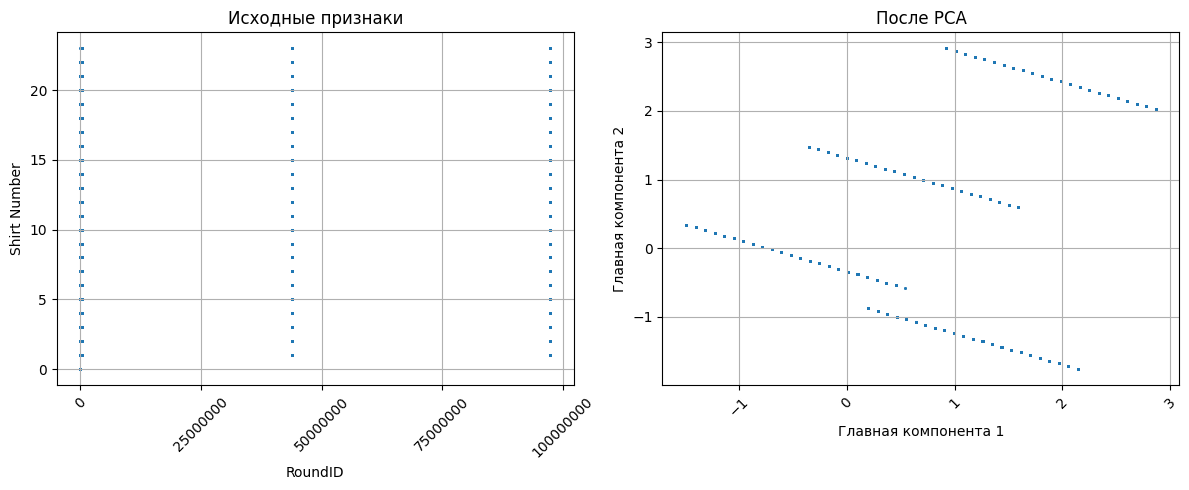

Сравнение:
- На исходном графике точки вытянуты вдоль RoundID, структура не видна.
- После PCA данные стали компактнее, первая компонента отражает основную вариацию.
- PCA улучшил визуализацию, убрав избыточную информацию.



In [ ]:
print("\n=== Задание 4. Визуализация данных ===\n")

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 2], alpha=0.5, s=1)
plt.xlabel('RoundID')
plt.ylabel('Shirt Number')
plt.title('Исходные признаки')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)
plt.locator_params(axis='x', nbins=5)

# После PCA
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=1)
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.title('После PCA')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='both')
plt.xticks(rotation=45)
plt.locator_params(axis='x', nbins=5)
plt.tight_layout()
plt.show()

print("Сравнение:")
print("- На исходном графике точки вытянуты вдоль RoundID, структура не видна.")
print("- После PCA данные стали компактнее, первая компонента отражает основную вариацию.")
print("- PCA улучшил визуализацию, убрав избыточную информацию.\n")

# Задание №5. Нелинейные методы снижения размерности


=== Задание 5. Нелинейные методы (t-SNE, UMAP) ===



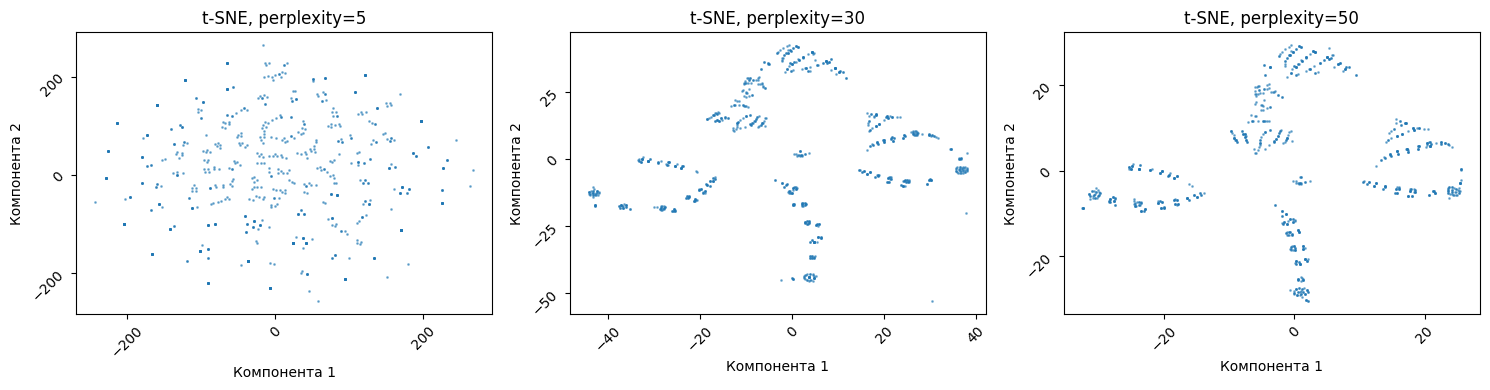

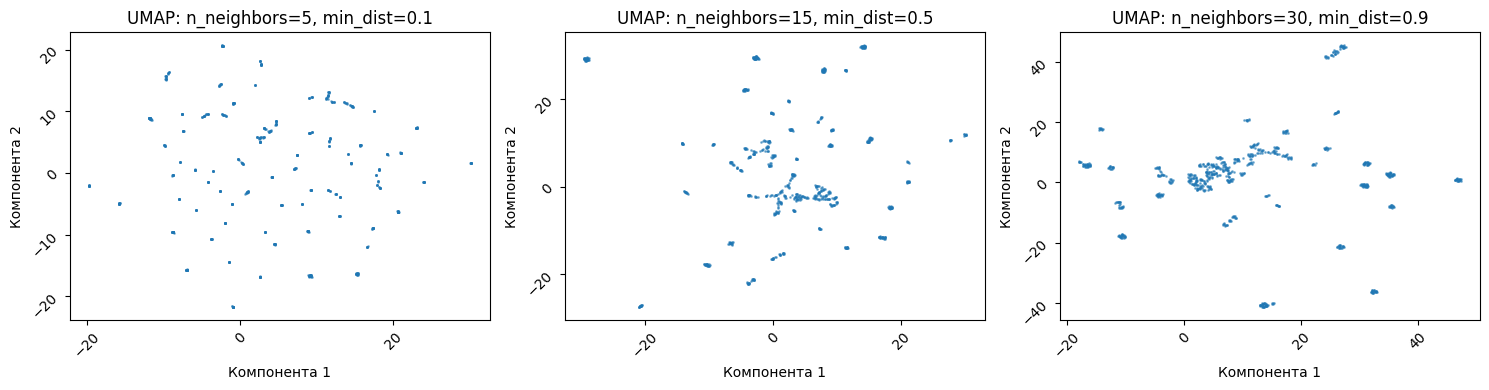

Анализ:
- При маленьком perplexity t-SNE дробит данные на много мелких групп.
- С ростом perplexity структура становится более сглаженной.
- UMAP при малых n_neighbors и min_dist даёт чёткие кластеры, при больших – более размытые.
- Методы дают разные результаты, потому что t-SNE сохраняет локальную структуру, а UMAP – и локальную, и глобальную.



In [ ]:
from sklearn.manifold import TSNE
import umap.umap_ as umap
warnings.filterwarnings('ignore')

print("\n=== Задание 5. Нелинейные методы (t-SNE, UMAP) ===\n")

sample_size = 5000
if X_scaled.shape[0] > sample_size:
    np.random.seed(42)
    idx_sample = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_sample = X_scaled[idx_sample]
else:
    X_sample = X_scaled

# t-SNE
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_sample)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=1)
    axes[i].set_title(f't-SNE, perplexity={perp}')
    axes[i].set_xlabel('Компонента 1')
    axes[i].set_ylabel('Компонента 2')
    axes[i].ticklabel_format(style='plain', axis='both')
    axes[i].tick_params(axis='both', rotation=45)
    axes[i].locator_params(axis='x', nbins=5)
    axes[i].locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.show()

# UMAP
n_neighbors_list = [5, 15, 30]
min_dist_list = [0.1, 0.5, 0.9]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (n, d) in enumerate(zip(n_neighbors_list, min_dist_list)):
    reducer = umap.UMAP(n_neighbors=n, min_dist=d, random_state=42)
    X_umap = reducer.fit_transform(X_sample)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=1)
    axes[i].set_title(f'UMAP: n_neighbors={n}, min_dist={d}')
    axes[i].set_xlabel('Компонента 1')
    axes[i].set_ylabel('Компонента 2')
    axes[i].ticklabel_format(style='plain', axis='both')
    axes[i].tick_params(axis='both', rotation=45)
    axes[i].locator_params(axis='x', nbins=5)
    axes[i].locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.show()

print("Анализ:")
print("- При маленьком perplexity t-SNE дробит данные на много мелких групп.")
print("- С ростом perplexity структура становится более сглаженной.")
print("- UMAP при малых n_neighbors и min_dist даёт чёткие кластеры, при больших – более размытые.")
print("- Методы дают разные результаты, потому что t-SNE сохраняет локальную структуру, а UMAP – и локальную, и глобальную.\n")

# Задание №6. Исследование степени сжатия данных


=== Задание 6. Сжатие данных и ошибка восстановления ===

k = 1 → MSE = 0.612741
k = 2 → MSE = 0.298553
k = 3 → MSE = 0.000000

Таблица ошибок восстановления:
Число компонент | Ошибка восстановления (MSE)
---------------------------------------------
       1        |      0.612741
       2        |      0.298553
       3        |      0.000000


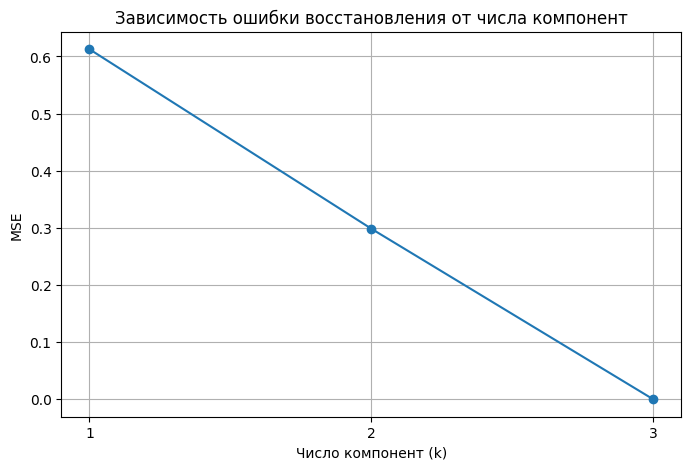


Выводы:
1. При k=1 ошибка наибольшая, т.к. теряется много информации.
2. При k=3 (все компоненты) ошибка равна 0 – данные восстанавливаются полностью.
3. Увеличение числа компонент уменьшает ошибку, потому что сохраняется больше дисперсии.
4. Оптимальное число компонент можно выбрать по графику ошибки (точка излома) или по накопленной дисперсии (например, 95%).



In [ ]:
from sklearn.metrics import mean_squared_error

print("\n=== Задание 6. Сжатие данных и ошибка восстановления ===\n")

k_values = [1, 2, 3]
errors = []

for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    errors.append(mse)
    print(f"k = {k} → MSE = {mse:.6f}")

print("\nТаблица ошибок восстановления:")
print("Число компонент | Ошибка восстановления (MSE)")
print("-" * 45)
for k, err in zip(k_values, errors):
    print(f"       {k}        |      {err:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, 'o-')
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE')
plt.title('Зависимость ошибки восстановления от числа компонент')
plt.grid(True)
plt.xticks(k_values)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)
plt.show()

print("\nВыводы:")
print("1. При k=1 ошибка наибольшая, т.к. теряется много информации.")
print("2. При k=3 (все компоненты) ошибка равна 0 – данные восстанавливаются полностью.")
print("3. Увеличение числа компонент уменьшает ошибку, потому что сохраняется больше дисперсии.")
print("4. Оптимальное число компонент можно выбрать по графику ошибки (точка излома) или по накопленной дисперсии (например, 95%).\n")

# Задание №7. Итоговый анализ

In [ ]:
print("\n=== Задание 7. Итоговый анализ ===\n")
print("Общие выводы по работе:")
print("1. Снижение размерности полезно для визуализации, удаления шума и ускорения алгоритмов.")
print("2. Однако слишком сильное сжатие приводит к потере важной информации.")
print("3. Линейные методы (PCA) эффективны, когда данные лежат на линейном подпространстве.")
print("4. Нелинейные методы (t-SNE, UMAP) лучше подходят для данных со сложной нелинейной структурой.")
print("5. Выбор метода и его параметров зависит от конкретной задачи и объёма данных.")
print("\nРекомендации:")
print("- Если нужно быстро уменьшить размерность и сохранить интерпретируемость – используйте PCA.")
print("- Для визуализации и поиска кластеров – t-SNE или UMAP (но их результаты чувствительны к параметрам).")
print("- Всегда проверяйте долю объяснённой дисперсии при использовании PCA.")


=== Задание 7. Итоговый анализ ===

Общие выводы по работе:
1. Снижение размерности полезно для визуализации, удаления шума и ускорения алгоритмов.
2. Однако слишком сильное сжатие приводит к потере важной информации.
3. Линейные методы (PCA) эффективны, когда данные лежат на линейном подпространстве.
4. Нелинейные методы (t-SNE, UMAP) лучше подходят для данных со сложной нелинейной структурой.
5. Выбор метода и его параметров зависит от конкретной задачи и объёма данных.

Рекомендации:
- Если нужно быстро уменьшить размерность и сохранить интерпретируемость – используйте PCA.
- Для визуализации и поиска кластеров – t-SNE или UMAP (но их результаты чувствительны к параметрам).
- Всегда проверяйте долю объяснённой дисперсии при использовании PCA.
